# ARFIMA — Fractional Integration and Long Memory

**ARFIMA(p, d, q)** (AutoRegressive Fractionally Integrated Moving Average) extends classical ARIMA models by allowing the differencing parameter *d* to take fractional values. This enables modeling of **long-memory processes**, where autocorrelations decay slowly (hyperbolically) rather than exponentially.

**Key Features:**
- **Fractional Parameter:** *d* ∈ (−0.5, 0.5) for stationarity
- **Long Memory:** 0 < *d* < 0.5 → positive persistence
- **Anti-Persistence:** −0.5 < *d* < 0 → mean reversion
- **Applications:** Financial volatility, hydrology, climate data, network traffic

This notebook demonstrates:
1. Generating ARFIMA series with BeTiSe
2. Comparing different *d* values and their impact on autocorrelation
3. Visualizing long-memory effects
4. Understanding the relationship between *d* and autocorrelation decay

---

## 1 · Setup and Imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

from betise import generate_dataframe
from betise.config import load_config

print("✓ BeTiSe imported successfully")

SyntaxError: duplicate argument 'ar_order' in function definition (metadata.py, line 63)

## 2 · Generate a Basic ARFIMA Series

Start with a simple ARFIMA series using default parameters (*d* ∈ [0.25, 0.49]).

In [2]:
# Generate a single ARFIMA series with 500 observations
cfg = load_config(dataset={
    "base_series": "arfima",
    "num_series": 1,
    "length_range": [500, 500]
})

df, ctx = generate_dataframe(cfg)

# Display metadata
print("Generated ARFIMA series:")
print(f"  Length: {len(df)}")

# Safely extract numeric metadata with NaN handling
ar_order = df['ar_order'].iloc[0]
d_param = df['d_parameter'].iloc[0]
ma_order = df['ma_order'].iloc[0]
long_mem = df['long_memory'].iloc[0]

print(f"  AR order (p): {int(ar_order) if pd.notna(ar_order) else 'N/A'}")
print(f"  Fractional d: {d_param:.4f}" if pd.notna(d_param) else "  Fractional d: N/A")
print(f"  MA order (q): {int(ma_order) if pd.notna(ma_order) else 'N/A'}")
print(f"  Long memory: {bool(int(long_mem)) if pd.notna(long_mem) else False}")

Generated ARFIMA series:
  Length: 500
  AR order (p): 2
  Fractional d: 0.4860
  MA order (q): 2
  Long memory: True


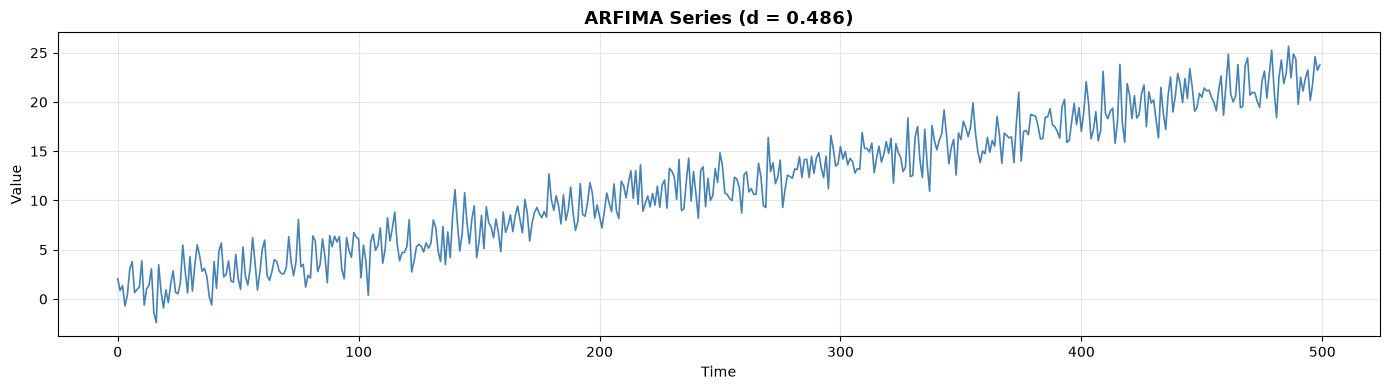

In [3]:
# Plot the series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["time"], df["data"], linewidth=1.2, color="steelblue")
ax.set_title(f"ARFIMA Series (d = {df['d_parameter'].iloc[0]:.3f})", 
             fontsize=13, fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3 · Compare Different *d* Values

Generate multiple ARFIMA series with varying *d* parameters to observe long-memory effects.

**Theory:** 
- Larger *d* (closer to 0.5) → stronger long memory → slower autocorrelation decay
- Smaller *d* (closer to 0) → weaker long memory → faster autocorrelation decay

In [5]:
# Generate 3 series with different d ranges
d_ranges = [
    ([0.10, 0.15], "Weak Long Memory"),
    ([0.30, 0.35], "Moderate Long Memory"),
    ([0.45, 0.49], "Strong Long Memory")
]

series_dict = {}

for d_range, label in d_ranges:
    cfg = load_config(dataset={
        "base_series": "arfima",
        "num_series": 1,
        "length_range": [500, 500]
    })
    # Override d_range in base params
    cfg["params"]["base"]["arfima"]["d_range"] = d_range
    
    df, ctx = generate_dataframe(cfg)
    d_val = df['d_parameter'].iloc[0]
    series_dict[label] = (df["data"].values, d_val)
    print(f"✓ Generated {label}: d = {d_val:.4f}")

✓ Generated Weak Long Memory: d = 0.1492
✓ Generated Moderate Long Memory: d = 0.3492
✓ Generated Strong Long Memory: d = 0.4893


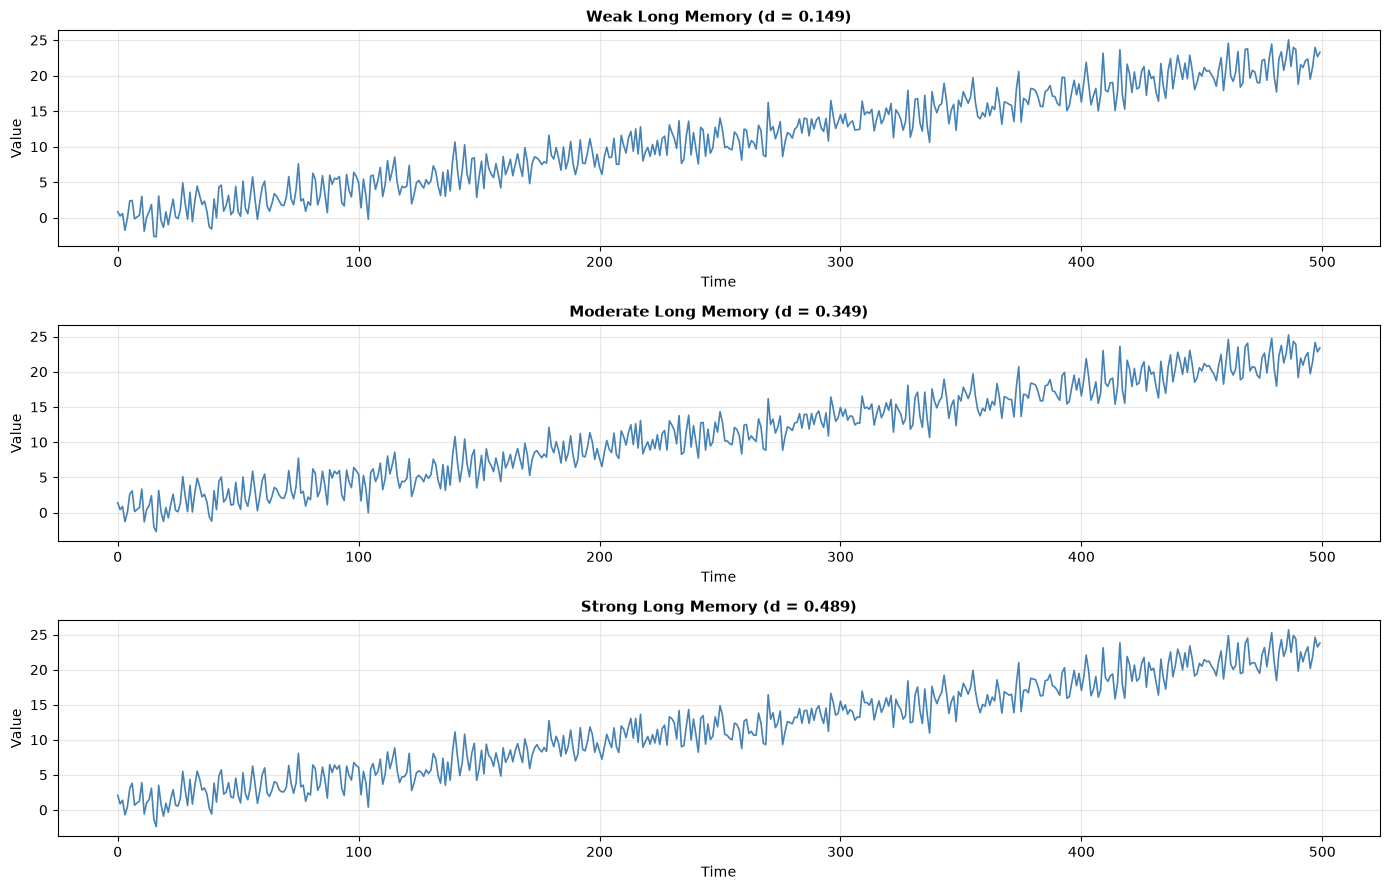

In [6]:
# Plot all three series
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

for idx, (label, (series, d_val)) in enumerate(series_dict.items()):
    axes[idx].plot(series, linewidth=1.2, color="steelblue")
    axes[idx].set_title(f"{label} (d = {d_val:.3f})", fontsize=11, fontweight="bold")
    axes[idx].set_xlabel("Time")
    axes[idx].set_ylabel("Value")
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4 · Autocorrelation Analysis

Visualize how autocorrelation decays differently for different *d* values. Long-memory processes show **slow, hyperbolic decay** rather than exponential decay.

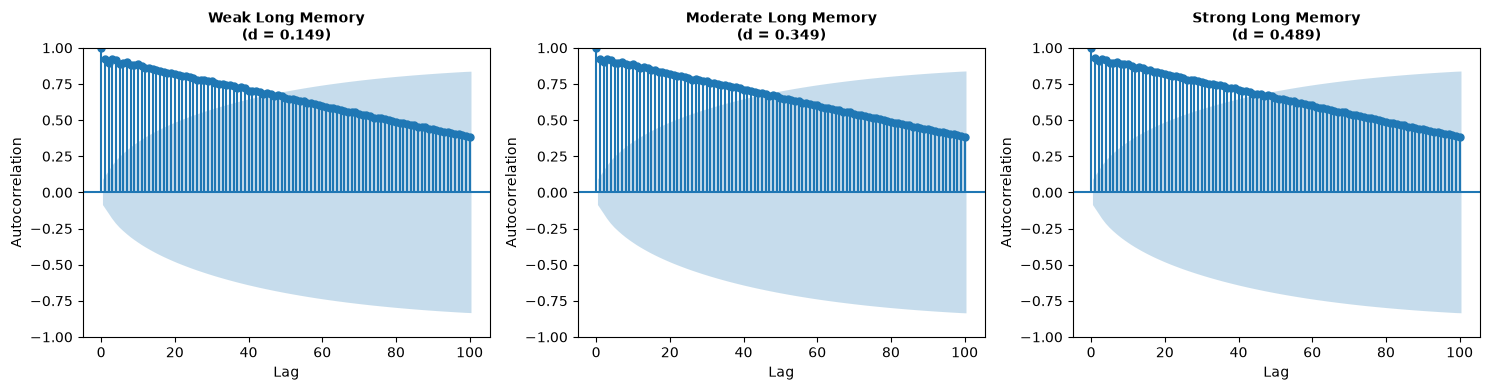


📊 Observation:
  → Higher d values show slower ACF decay (long memory)
  → Lower d values show faster ACF decay (short memory)


In [7]:
# Plot ACF for each series
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (label, (series, d_val)) in enumerate(series_dict.items()):
    plot_acf(series, lags=100, ax=axes[idx], alpha=0.05)
    axes[idx].set_title(f"{label}\n(d = {d_val:.3f})", fontsize=10, fontweight="bold")
    axes[idx].set_xlabel("Lag")
    axes[idx].set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

print("\n📊 Observation:")
print("  → Higher d values show slower ACF decay (long memory)")
print("  → Lower d values show faster ACF decay (short memory)")

## 5 · Generate ARFIMA with Specific Parameters

You can also generate ARFIMA series programmatically using the core API:

In [ ]:
from betise.core.generator import TimeSeriesGenerator

# Initialize generator with reproducible seed
np.random.seed(42)
ts_gen = TimeSeriesGenerator(length=600)

# Generate ARFIMA series with custom d range
df_arfima, info = ts_gen.generate_fractional_process(
    kind="arfima",
    d_range=(0.35, 0.40),  # Specific d range
    alpha=0,               # additive series constant (the process mean)
    numseas=100            # burn-in samples, generated then discarded
)

print("Generated ARFIMA series:")
print(df_arfima.head())
print(f"\nSeries length: {len(df_arfima)}")

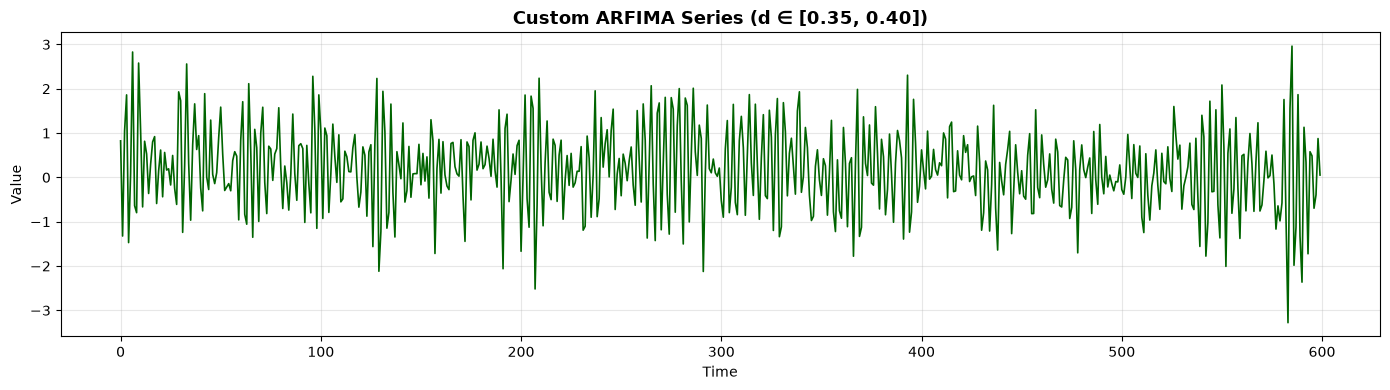

In [11]:
# Plot the custom ARFIMA series
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_arfima["time"], df_arfima["data"], linewidth=1.2, color="darkgreen")
ax.set_title("Custom ARFIMA Series (d ∈ [0.35, 0.40])", fontsize=13, fontweight="bold")
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6 · Long Memory in Practice

Long-memory processes are common in:

- **Finance:** Volatility clustering (GARCH models with long memory)
- **Hydrology:** River flow persistence
- **Climate:** Temperature anomalies
- **Networks:** Internet traffic patterns
- **Economics:** Inflation persistence

**Key Insight:** When autocorrelations decay slowly (hyperbolically), past shocks have lasting effects on future values. Standard ARMA/ARIMA models cannot capture this behavior, but ARFIMA can.

---

### Summary

✓ ARFIMA models extend ARIMA with fractional differencing  
✓ Parameter *d* controls long-memory strength (0 < *d* < 0.5)  
✓ Autocorrelations decay hyperbolically (not exponentially)  
✓ BeTiSe generates ARFIMA series with stationary/invertible AR/MA coefficients  
✓ Use `base_series='arfima'` in config or call `generate_fractional_process()` directly

**Next Steps:**
- Combine ARFIMA with trends, seasonality, or anomalies
- Use ARFIMA series for forecasting model benchmarks
- Study forecast performance degradation with increasing *d*

For more details, see **Appendix E** in `APPENDIX.md`.